In [1]:
!pip install -q sentence-transformers scikit-learn pandas numpy datasets joblib

In [ ]:
""" import os
import re
import json
import time
import random
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

import torch

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ All libraries loaded")
print(f"🖥️  Device: {device} ({'GPU ⚡' if device == 'cuda' else 'CPU 🐢 — Enable GPU: Runtime > Change runtime type > T4'})")
if device == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB") """

✅ All libraries loaded
🖥️  Device: cpu (CPU 🐢 — Enable GPU: Runtime > Change runtime type > T4)


In [3]:
from datasets import load_dataset

print("📥 Loading real e-commerce product datasets...")
print("   This downloads real Amazon product metadata.\n")

all_dfs = []

categories_to_load = [
    "raw_meta_All_Beauty",
    "raw_meta_Electronics",
    "raw_meta_Clothing_Shoes_and_Jewelry",
    "raw_meta_Home_and_Kitchen",
    "raw_meta_Sports_and_Outdoors",
    "raw_meta_Grocery_and_Gourmet_Food",
    "raw_meta_Tools_and_Home_Improvement",
    "raw_meta_Health_and_Personal_Care",
]

for cat_name in categories_to_load:
    nice_name = cat_name.replace('raw_meta_', '').replace('_', ' ')
    try:
        ds = load_dataset(
            "McAuley-Lab/Amazon-Reviews-2023",
            cat_name,
            split="full",
            trust_remote_code=True
        )
        cat_df = ds.to_pandas()
        # Sample to keep total manageable
        if len(cat_df) > 6000:
            cat_df = cat_df.sample(n=6000, random_state=42)
        all_dfs.append(cat_df)
        print(f"   ✅ {nice_name}: {len(cat_df):,} products")
    except Exception as e:
        print(f"   ⚠️  {nice_name}: skipped ({type(e).__name__}: {str(e)[:80]})")

if all_dfs:
    raw_df = pd.concat(all_dfs, ignore_index=True)
    print(f"\n📊 Total loaded: {len(raw_df):,} products")
else:
    raw_df = pd.DataFrame()
    print("\n⚠️  HuggingFace datasets unavailable. Will use fallback in next cell.")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


📥 Loading real e-commerce product datasets...
   This downloads real Amazon product metadata.



README.md: 0.00B [00:00, ?B/s]

Amazon-Reviews-2023.py: 0.00B [00:00, ?B/s]

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR

   ⚠️  All Beauty: skipped (RuntimeError: Dataset scripts are no longer supported, but found Amazon-Reviews-2023.py)
   ⚠️  Electronics: skipped (RuntimeError: Dataset scripts are no longer supported, but found Amazon-Reviews-2023.py)
   ⚠️  Clothing Shoes and Jewelry: skipped (RuntimeError: Dataset scripts are no longer supported, but found Amazon-Reviews-2023.py)
   ⚠️  Home and Kitchen: skipped (RuntimeError: Dataset scripts are no longer supported, but found Amazon-Reviews-2023.py)


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR

   ⚠️  Sports and Outdoors: skipped (RuntimeError: Dataset scripts are no longer supported, but found Amazon-Reviews-2023.py)
   ⚠️  Grocery and Gourmet Food: skipped (RuntimeError: Dataset scripts are no longer supported, but found Amazon-Reviews-2023.py)
   ⚠️  Tools and Home Improvement: skipped (RuntimeError: Dataset scripts are no longer supported, but found Amazon-Reviews-2023.py)
   ⚠️  Health and Personal Care: skipped (RuntimeError: Dataset scripts are no longer supported, but found Amazon-Reviews-2023.py)

⚠️  HuggingFace datasets unavailable. Will use fallback in next cell.


In [4]:
# ── Fallback: If HuggingFace failed, generate a large diverse synthetic dataset ──

if len(raw_df) == 0:
    print("📦 Building comprehensive synthetic e-commerce dataset...")
    print("   This covers 8 major product domains with realistic data.\n")

    domains = {
        'Electronics': [
            ('Wireless Bluetooth Headphones', 'Premium over-ear wireless headphones active noise cancellation 40mm drivers 30-hour battery foldable design microphone'),
            ('USB-C Fast Charging Cable 6ft', 'Durable braided nylon USB-C cable 100W power delivery 480Mbps data transfer compatible all devices'),
            ('Portable Power Bank 20000mAh', 'High capacity portable charger dual USB-A USB-C ports LED display fast charging airline approved'),
            ('Smart Watch Fitness Tracker', 'Advanced smartwatch heart rate GPS sleep analysis blood oxygen 14-day battery water resistant 50m'),
            ('Mechanical Gaming Keyboard RGB', 'Full-size mechanical keyboard hot-swappable switches per-key RGB aluminum frame programmable macros'),
            ('4K Webcam Ring Light', 'Ultra HD webcam built-in adjustable ring light auto-focus AI framing dual microphones USB-C plug-play'),
            ('Wireless Ergonomic Mouse', 'Vertical ergonomic wireless mouse 4000 DPI silent clicks Bluetooth USB dual mode programmable buttons'),
            ('Laptop Cooling Pad 17-inch', 'Slim laptop cooling pad 5 quiet fans adjustable height RGB lighting dual USB fits 17 inch notebooks'),
            ('Portable Bluetooth Speaker Waterproof', 'Compact waterproof Bluetooth 360 sound IP67 24-hour playtime stereo pairing outdoor speaker'),
            ('True Wireless Earbuds ANC', 'Premium true wireless earbuds hybrid noise cancelling balanced armature drivers wireless charging IPX5'),
            ('USB-C Hub Multiport Adapter', 'USB-C hub HDMI 4K 100W power delivery USB-A SD card reader Ethernet aluminum travel docking station'),
            ('Portable SSD 1TB NVMe', 'Ultra-fast portable NVMe SSD 1050MB/s rugged aluminum IP65 USB-C hardware encryption external drive'),
            ('Smart Home Display 10-inch', 'Smart display AI assistant voice control video calling streaming stereo speakers smart home hub'),
            ('Wireless Charging Pad 15W', 'Dual wireless charging pad Qi MagSafe 15W fast charge LED indicator fabric finish charges phone earbuds'),
            ('Action Camera 4K Waterproof', 'Rugged 4K 60fps action camera stabilization waterproof 10m front rear LCD voice control live streaming'),
            ('E-Reader Waterproof 7-inch', 'Premium e-reader 7-inch flush display warm light waterproof IPX8 32GB weeks battery adjustable light'),
            ('Mini Projector 1080p', 'Compact HD mini projector 200 ANSI lumens auto keystone built-in speaker streaming apps 120-inch screen'),
            ('Noise Cancelling Earbuds Pro', 'Active noise cancellation earbuds transparency mode spatial audio 8-hour battery wireless charging case'),
            ('Mechanical Numpad RGB', 'Wireless mechanical number pad hot-swap RGB Bluetooth USB-C compact accounting data entry programmable'),
            ('Monitor Light Bar LED', 'Screen light bar no glare asymmetric LED design auto-dimming adjustable color temperature USB powered'),
        ],
        'Clothing': [
            ('Premium Cotton T-Shirt Crew Neck', 'Soft 100% organic combed cotton crew neck pre-shrunk double-stitch breathable everyday casual wear'),
            ('Slim Fit Stretch Denim Jeans', 'Modern slim fit jeans 2% elastane stretch 5-pocket design brass hardware mid-rise comfortable'),
            ('Wool Blend Winter Overcoat', 'Double-breasted wool blend overcoat satin lining notch lapel deep pockets tailored cold weather'),
            ('Athletic Running Shorts', 'Lightweight moisture-wicking running shorts built-in liner zippered pocket reflective 5-inch inseam'),
            ('Cashmere V-Neck Sweater', 'Luxurious pure cashmere V-neck pullover ribbed cuffs hem lightweight warmth dry clean seasonal colors'),
            ('Formal Dress Shirt Wrinkle-Free', 'Wrinkle-free cotton blend shirt spread collar French cuffs tailored fit business formal events'),
            ('Waterproof Rain Jacket Packable', 'Seam-sealed waterproof rain jacket adjustable hood mesh lining packable pocket reflective trim travel'),
            ('Canvas Low-Top Sneakers Classic', 'Classic canvas sneakers vulcanized rubber sole padded collar cotton laces ortholite insole comfort'),
            ('High-Waist Yoga Leggings', 'Buttery soft high-waist yoga leggings 4-way stretch hidden pocket squat-proof moisture wicking'),
            ('Leather Chelsea Boots', 'Genuine leather Chelsea boots elastic side panels cushioned insole rubber outsole British heritage'),
            ('Silk Blend Tie Set', 'Premium silk blend necktie set with matching pocket square and cufflinks business formal occasions'),
            ('Puffer Down Jacket Lightweight', 'Packable lightweight down puffer jacket 700 fill power water-resistant shell elastic cuffs travel'),
            ('Linen Beach Shorts', 'Relaxed linen shorts elastic waistband drawstring breathable warm weather side pockets casual'),
            ('Performance Polo Shirt', 'Moisture-wicking performance polo UPF 50 stretch fabric collar sport golf office casual versatile'),
            ('Merino Wool Dress Socks', 'Premium merino wool dress socks temperature regulating moisture-wicking reinforced cushioned formal'),
            ('Fleece Zip-Up Hoodie', 'Heavyweight fleece zip-up hoodie kangaroo pockets ribbed cuffs drawstring hood warm layering casual'),
            ('Tailored Chino Pants', 'Classic straight-leg chino pants premium twill cotton pressed crease versatile office weekend wear'),
            ('Suede Desert Boots', 'Genuine suede desert boots crepe rubber sole ankle height lace-up classic minimalist style'),
            ('Athletic Compression Shirt', 'Compression base layer long sleeve moisture-wicking 4-way stretch flatlock seams workout training'),
            ('Reversible Leather Belt', 'Full-grain leather reversible belt black brown brushed nickel buckle fits 44 inches classic accessory'),
        ],
        'Home & Kitchen': [
            ('Stainless Steel Cookware Set 10pc', 'Professional tri-ply stainless steel cookware pots pans lids induction compatible oven safe 500F'),
            ('Air Fryer Digital 6-Quart', 'Family size digital air fryer 8 presets rapid air circulation non-stick basket dishwasher safe'),
            ('Memory Foam Contour Pillow', 'Cervical memory foam pillow ergonomic contour cooling gel hypoallergenic bamboo cover washable'),
            ('Robot Vacuum Smart Navigation', 'WiFi robot vacuum LiDAR 2500Pa suction self-charging voice assistant HEPA filter smart mapping'),
            ('Cast Iron Skillet 12-inch', 'Pre-seasoned cast iron skillet heat-resistant handle pour spouts oven campfire safe even heat'),
            ('LED Desk Lamp Dimmable', 'LED desk lamp 5 brightness 3 color temperatures USB charging memory function eye-care modern'),
            ('Bamboo Cutting Board Set', 'Organic bamboo cutting board set 3 sizes juice groove antimicrobial handles eco-friendly sustainable'),
            ('Programmable Coffee Maker', 'Programmable drip coffee maker thermal carafe 12-cup auto shut-off built-in grinder bold brew'),
            ('Egyptian Cotton Sheet Set 800TC', '800-thread-count Egyptian cotton sheets sateen weave deep pocket breathable luxuriously soft'),
            ('Scented Soy Candle Set', 'Hand-poured natural soy candles essential oils vanilla lavender eucalyptus 50-hour burn glass jars'),
            ('Non-stick Cookware Set 12pc', 'Diamond-infused nonstick cookware all cooktops induction oven safe PFOA-free metal utensil safe'),
            ('Smart Thermostat WiFi', 'Energy-saving smart thermostat learning capability room sensor voice control saves 23% energy bills'),
            ('Espresso Machine Automatic', 'Automatic espresso machine conical burr grinder 15-bar Italian pump PID temperature steam wand'),
            ('Kitchen Knife Set 15-piece', 'Precision-forged German steel knife set hardwood block full-tang ergonomic handles kitchen shears'),
            ('Weighted Blanket 20 lbs', 'Premium weighted blanket glass beads evenly distributed breathable cotton cover reduces anxiety sleep'),
            ('Immersion Hand Blender', 'Powerful immersion blender variable speed stainless steel blade whisk attachment chopper smoothie soup'),
            ('Ceramic Plant Pot Set', 'Modern ceramic plant pots with drainage holes and saucers set of 3 sizes minimalist indoor planters'),
            ('Water Filter Pitcher', 'Advanced water filter pitcher removes 99% contaminants BPA-free fast filtration 10-cup capacity'),
            ('Silicone Baking Mat Set', 'Non-stick silicone baking mats set of 3 reusable heat-resistant macaron cookie sheet liner eco-friendly'),
            ('Electric Kettle Temperature', 'Variable temperature electric kettle stainless steel 1.7L quick boil keep warm gooseneck pour-over'),
        ],
        'Sports & Outdoors': [
            ('Yoga Mat Non-Slip Premium 6mm', 'Extra thick yoga mat alignment lines TPE eco-friendly non-slip carrying strap exercise meditation'),
            ('Adjustable Dumbbell Set 52.5lbs', 'Space-saving adjustable dumbbells 5-52.5 lbs dial mechanism replaces 15 pairs strength training'),
            ('Camping Tent 4-Person Instant', 'Waterproof 4-person tent instant setup rainfly mesh windows gear loft electric cord camping outdoor'),
            ('Resistance Bands Set 5-Level', 'Professional resistance bands 5 levels TPE latex-free handles door anchor ankle straps carry bag'),
            ('Hiking Backpack 40L Ventilated', 'Lightweight hiking backpack ventilated back rain cover hydration compatible hip belt compartments'),
            ('Foam Roller Muscle Recovery', 'High-density EVA foam roller textured deep tissue massage trigger points 18-inch lightweight portable'),
            ('Running Shoes Cushioned Mesh', 'Responsive cushioning running shoes engineered mesh energy-return midsole rubber outsole reflective'),
            ('Swimming Goggles Anti-Fog UV', 'Competition swim goggles anti-fog UV protection silicone strap adjustable nose bridge clear lenses'),
            ('Indoor Cycling Bike Magnetic', 'Belt-drive indoor cycling magnetic resistance LCD monitor adjustable seat handlebars transport wheels'),
            ('Jump Rope Speed Ball-Bearing', 'Speed jump rope ball-bearing swivel adjustable steel cable foam grips HIIT boxing crossfit training'),
            ('Pull-Up Bar Doorway', 'Multi-grip pull-up bar doorway mount no screws foam padded handles supports 300 lbs chin-up fitness'),
            ('Insulated Water Bottle 32oz', 'Vacuum insulated stainless steel water bottle 32oz keeps cold 24hr hot 12hr BPA-free leak-proof'),
            ('Trekking Poles Lightweight', 'Carbon fiber trekking poles adjustable lightweight cork grip wrist strap tungsten tips all-terrain'),
            ('Badminton Racket Set', 'Professional badminton racket set 2 rackets 3 shuttlecocks carrying case lightweight graphite frame'),
            ('Kayak Paddle Adjustable', 'Lightweight aluminum kayak paddle adjustable length fiberglass blades drip rings asymmetrical design'),
            ('Ab Roller Wheel Core', 'Ab roller wheel with knee pad dual wheels non-slip handles core workout strengthening exercise'),
            ('Sleeping Bag 3-Season', 'Mummy sleeping bag 3-season 20F lightweight compressible water-resistant fill compression sack'),
            ('Basketball Official Indoor/Outdoor', 'Official size basketball composite leather deep channel grip consistent bounce indoor outdoor play'),
            ('Bicycle Lock Heavy Duty', 'Heavy duty U-lock bicycle lock 16mm hardened steel shackle anti-theft mounting bracket 2 keys'),
            ('Fishing Rod Reel Combo', 'Spinning fishing rod reel combo 7ft medium action graphite blank smooth drag system all-water fishing'),
        ],
        'Grocery': [
            ('Organic Extra Virgin Olive Oil 1L', 'Cold-pressed extra virgin olive oil certified organic Mediterranean rich fruity flavor first pressing'),
            ('Premium Basmati Rice 5kg', 'Aged long-grain basmati rice aromatic fluffy non-GMO gluten-free biryani pilaf everyday cooking'),
            ('Dark Chocolate 72% Single-Origin', 'Single-origin 72% dark chocolate ethically sourced smooth rich antioxidant vegan craft artisan'),
            ('Japanese Green Tea Collection', 'Assorted Japanese green tea sencha matcha genmaicha hojicha 40 individually wrapped sachets premium'),
            ('Raw Wildflower Honey', 'Unfiltered raw wildflower honey never heated natural enzymes antioxidants local sustainable apiaries'),
            ('Mixed Nuts Trail Pack Premium', 'Premium trail mix almonds cashews walnuts pecans cranberries lightly salted protein energy snack'),
            ('Cold Brew Coffee Concentrate', 'Smooth cold brew single-origin low acidity chocolate caramel notes concentrate makes 12 cups'),
            ('Organic Quinoa Tri-Color', 'Certified organic tri-color quinoa complete protein essential amino acids pre-washed superfood grain'),
            ('Aged Balsamic Vinegar Modena', 'Traditionally aged balsamic vinegar Modena 12-year oak barrels sweet tangy finishing dressing salad'),
            ('Organic Coconut Milk', 'Rich creamy organic coconut milk no preservatives BPA-free essential curries smoothies baking'),
            ('Granola Clusters Maple Pecan', 'Crunchy granola clusters maple syrup toasted pecans whole grain oats flax seeds no HFCS breakfast'),
            ('Matcha Powder Ceremonial Grade', 'Ceremonial grade matcha stone-ground Japanese green tea vibrant color umami flavor latte baking'),
            ('Almond Butter Creamy', 'All-natural creamy almond butter roasted almonds no added sugar salt oil protein healthy spread'),
            ('Chia Seeds Organic 1kg', 'Organic black chia seeds omega-3 fiber protein calcium antioxidants smoothie pudding superfood'),
            ('Italian Pasta Artisan Bronze-Cut', 'Bronze-cut Italian pasta semolina durum wheat slow-dried rough texture sauce-clinging artisan'),
            ('Sea Salt Flakes Gourmet', 'Hand-harvested gourmet sea salt flakes pyramid crystals finishing salt mineral-rich Mediterranean'),
            ('Protein Bars Variety Pack', 'High protein bars 20g protein variety pack low sugar natural ingredients gluten-free gym recovery'),
            ('Turmeric Powder Organic', 'Certified organic turmeric powder high curcumin content anti-inflammatory spice cooking golden milk'),
            ('Dried Mango Slices', 'Natural dried mango slices no added sugar preservatives tropical fruit snack fiber vitamins chewy'),
            ('Coconut Water Natural 12-Pack', 'Pure natural coconut water no added sugar electrolytes potassium hydration refreshing tropical'),
        ],
        'Furniture': [
            ('Mid-Century Modern Sofa', 'Mid-century sofa walnut legs velvet upholstery high-resilience foam seats 3 modern living room'),
            ('Ergonomic Office Chair Mesh', 'Mesh back ergonomic chair adjustable lumbar 4D armrests synchro-tilt 300 lbs capacity office'),
            ('Solid Oak Dining Table', 'Handcrafted solid white oak dining table natural grain extension leaf seats 6-8 mortise tenon'),
            ('Queen Memory Foam Mattress', '12-inch cooling gel memory foam mattress CertiPUR-US motion isolation hypoallergenic 10-year'),
            ('Industrial Bookshelf 5-Tier', 'Industrial metal wood bookshelf rustic brown 5-tier anti-tip anchor 50 lbs per shelf display'),
            ('Standing Desk Electric Dual Motor', 'Electric height-adjustable desk dual motors memory presets 60x30 desktop cable management sit-stand'),
            ('Rattan Accent Chair Cushioned', 'Handwoven rattan accent chair cushioned seat bohemian coastal weather-resistant washable cover'),
            ('Floating Wall Shelves Wood Set', 'Floating shelves set 3 hidden brackets solid wood walnut finish graduated sizes modern minimalist'),
            ('Velvet Storage Ottoman', 'Tufted velvet storage ottoman hidden compartment gold legs multi-functional seating decor bedroom'),
            ('King Platform Bed Upholstered', 'Modern king platform bed upholstered wingback headboard no box spring slat support noise-free'),
            ('Scandinavian Coffee Table Pine', 'Minimalist Scandinavian coffee table pine legs white top lower shelf compact small space living'),
            ('Outdoor Patio Dining Set 7pc', 'Outdoor dining set 7-piece aluminum wicker UV-resistant cushions tempered glass rust fade resistant'),
            ('Nursery Rocking Chair Glider', 'Comfortable nursery glider rocking chair padded armrests lumbar pillow smooth motion quiet baby'),
            ('TV Console Media Stand', 'Modern TV console media stand 65-inch cable management adjustable shelves solid wood legs entertainment'),
            ('Entryway Shoe Storage Bench', 'Entryway bench with shoe storage compartments cushioned seat coat hooks mudroom organizer bamboo'),
            ('Round Side Table Marble', 'Round marble-top side table gold metal base accent table living room bedroom nightstand modern'),
            ('Wardrobe Closet Freestanding', 'Freestanding wardrobe closet hanging rod shelves drawers mirror full-size portable bedroom storage'),
            ('Outdoor Lounge Chair Reclining', 'Adjustable outdoor lounge chair reclining all-weather wicker cushioned pool patio garden relaxation'),
            ('Writing Desk Minimalist', 'Minimalist writing desk solid wood drawer clean lines home office study small apartment compact'),
            ('Bar Stools Counter Height Set', 'Counter height bar stools set of 2 upholstered swivel footrest metal frame modern kitchen island'),
        ],
        'Beauty': [
            ('Vitamin C Brightening Serum 20%', '20% Vitamin C serum hyaluronic acid vitamin E brightens dark spots lightweight dermatologist tested'),
            ('Retinol Night Cream 0.5%', 'Advanced encapsulated retinol night cream fine lines wrinkles niacinamide peptides gradual release'),
            ('SPF 50 Lightweight Sunscreen', 'Broad-spectrum SPF 50 lightweight no white cast water-resistant 80 minutes reef-safe all skin tones'),
            ('Argan Oil Hair Treatment', 'Pure cold-pressed Moroccan argan oil frizz control heat protection lightweight shine all hair types'),
            ('Matte Liquid Lipstick Set 6pc', 'Long-wearing matte liquid lipstick 6 shades transfer-proof 12-hour vitamin E vegan cruelty-free'),
            ('Exfoliating Face Cleanser', 'Daily exfoliating face wash salicylic acid unclogs pores prevents breakouts pH-balanced aloe vera'),
            ('Hydrating Face Moisturizer', 'Intensive hydrating cream ceramides squalane 72-hour moisture fragrance-free non-comedogenic'),
            ('Professional Makeup Brush Set 12pc', 'Professional 12-piece synthetic brush set face eye lip brushes vegan leather case cruelty-free'),
            ('Hair Repair Mask Overnight', 'Intensive overnight hair mask keratin biotin repairs damage heat color deep conditioning treatment'),
            ('Eau de Parfum Floral', 'Sophisticated floral eau de parfum jasmine peony white musk long-lasting 8+ hours 50ml elegant'),
            ('Hyaluronic Acid Serum', 'Multi-weight hyaluronic acid serum deep hydration plumping lightweight layering all skin types daily'),
            ('Setting Spray Matte Finish', 'Long-lasting makeup setting spray matte finish controls shine 16-hour wear fine mist lightweight'),
            ('Lip Balm SPF 15 Tinted', 'Moisturizing tinted lip balm SPF 15 sun protection natural color beeswax shea butter nourishing'),
            ('Hair Dryer Professional Ionic', 'Professional ionic hair dryer 1875W fast drying reduce frizz lightweight concentrator diffuser'),
            ('Eye Cream Anti-Aging', 'Anti-aging eye cream peptides caffeine reduces puffiness dark circles fine lines lightweight gentle'),
            ('Nail Polish Set Gel Effect', 'Gel-effect nail polish set 8 colors long-lasting chip-resistant glossy finish quick-dry formula'),
            ('Body Lotion Shea Butter', 'Luxurious body lotion shea butter cocoa butter 24-hour moisture fast-absorbing non-greasy fragrance'),
            ('Micellar Water Cleansing', 'Gentle micellar cleansing water removes makeup dirt oil no-rinse soothing all skin types sensitive'),
            ('Brow Pencil Ultra-Fine', 'Ultra-fine brow pencil natural hair-like strokes waterproof built-in spoolie brush long-lasting'),
            ('Face Sheet Mask Variety Pack', 'Sheet mask variety pack 10 masks hydrating brightening soothing nourishing Korean skincare ritual'),
        ],
        'Books': [
            ('Atomic Habits Bestseller', 'Building good habits breaking bad ones practical strategies backed by science framework improving daily'),
            ('Python Programming Complete Guide', 'Comprehensive Python beginner to advanced algorithms web development machine learning 500+ exercises'),
            ('World Atlas Illustrated Children', 'Illustrated world atlas kids 6-12 continents countries cultures wildlife interactive activities'),
            ('Science Fiction Box Set Award-Winning', 'Box set 5 award-winning sci-fi novels classic contemporary special edition author introductions'),
            ('Meditation Mindfulness Guide', 'Practical mindfulness meditation 30-day program evidence-based stress reduction audio exercises'),
            ('Business Strategy Modern Essentials', 'Business strategy Fortune 500 case studies digital transformation innovation MBA-level accessible'),
            ('Mediterranean Diet Cookbook', 'Mediterranean diet cookbook 200+ recipes meal plans weight management heart health nutritional info'),
            ('Financial Freedom Blueprint', 'Personal finance investing guide budgeting strategies passive income retirement planning wealth building'),
            ('Classic Literature Collection Hardcover', 'Hardcover collection 10 timeless classics Pride Prejudice 1984 Great Expectations literary canon'),
            ('Self-Help Personal Growth Development', 'Transformative personal development emotional intelligence resilience achieving potential mindset'),
            ('Graphic Novel Manga Series', 'Popular manga graphic novel series action adventure fantasy beautiful artwork compelling storyline'),
            ('Travel Photography Coffee Table Book', 'Stunning travel photography coffee table book landscapes cultures landmarks around the world 300 pages'),
            ('Children Bedtime Story Collection', 'Bedtime story collection for children illustrated fairy tales adventures soothing read-aloud 5-8'),
            ('Data Science Machine Learning Textbook', 'Data science machine learning comprehensive textbook statistics neural networks deep learning Python R'),
            ('Historical Fiction Bestselling Novel', 'Bestselling historical fiction novel World War II era love courage resilience beautifully written'),
            ('Keto Diet Cookbook Quick Meals', 'Ketogenic diet cookbook quick 30-minute meals low-carb high-fat recipes nutritional macros meal prep'),
            ('Leadership Management Handbook', 'Leadership and management handbook team building decision making organizational behavior executive'),
            ('Yoga Anatomy Illustrated Guide', 'Yoga anatomy illustrated guide muscles poses alignment breathing technique safe practice progression'),
            ('Mystery Thriller Suspense Novel', 'Gripping mystery thriller suspense novel detective investigation twists turns page-turner bestseller'),
            ('DIY Home Improvement Guide', 'Complete DIY home improvement guide plumbing electrical painting renovation step-by-step illustrated'),
        ],
    }

    products = []
    for category, items in domains.items():
        for name, desc in items:
            # Create original + 4 variations = 5 per product, 800 total
            for v in range(5):
                vname = name if v == 0 else f"{name} {'Pro' if v==1 else 'Lite' if v==2 else 'Plus' if v==3 else 'Max'}"
                vdesc = desc if v == 0 else f"{desc} {'enhanced performance upgraded' if v==1 else 'budget friendly value' if v==2 else 'additional features premium' if v==3 else 'top tier ultimate edition'}"
                products.append({
                    'title': vname,
                    'description': vdesc,
                    'main_category': category,
                    'average_rating': round(random.uniform(3.0, 5.0), 1),
                    'rating_number': random.randint(10, 5000),
                })

    raw_df = pd.DataFrame(products)
    print(f"✅ Generated {len(raw_df):,} products across {len(domains)} categories")

print(f"\n📊 Dataset: {len(raw_df):,} products")
print(f"📋 Columns: {list(raw_df.columns[:8])}")

📦 Building comprehensive synthetic e-commerce dataset...
   This covers 8 major product domains with realistic data.

✅ Generated 800 products across 8 categories

📊 Dataset: 800 products
📋 Columns: ['title', 'description', 'main_category', 'average_rating', 'rating_number']


In [5]:
# ── Standardize column names ──
column_mapping = {
    'title': 'name',
    'main_category': 'category',
    'average_rating': 'rating',
    'rating_number': 'num_ratings',
    'product_name': 'name',
    'product_category_tree': 'category',
}
df = raw_df.rename(columns={k: v for k, v in column_mapping.items() if k in raw_df.columns})

for col in ['name', 'description', 'category']:
    if col not in df.columns:
        df[col] = ''

# ── Clean text ──
def clean_text(text):
    if not isinstance(text, str) or pd.isna(text):
        return ''
    if text.startswith('['):
        try:
            items = eval(text)
            if isinstance(items, list):
                text = ' '.join(str(i) for i in items)
        except:
            pass
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("🔄 Cleaning data...")
df['name'] = df['name'].apply(clean_text)
df['description'] = df['description'].apply(clean_text)
df['category'] = df['category'].apply(clean_text)

df = df[df['name'].str.len() > 3].reset_index(drop=True)
df = df.drop_duplicates(subset='name', keep='first').reset_index(drop=True)

# ── Create combined text ──
def create_product_text(row):
    parts = []
    name = str(row.get('name', ''))
    if name:
        parts.extend([name, name])  # 2x weight on name
    cat = str(row.get('category', ''))
    if cat:
        parts.append(f"Category: {cat}")
    desc = str(row.get('description', ''))
    if desc and len(desc) > 5:
        parts.append(desc[:500])
    return ' '.join(parts)

df['combined_text'] = df.apply(create_product_text, axis=1)

# Cap to 50K
if len(df) > 50000:
    df = df.groupby('category', group_keys=False).apply(
        lambda x: x.sample(min(len(x), max(100, int(50000 * len(x) / len(df)))), random_state=42)
    ).reset_index(drop=True)

print(f"✅ Final dataset: {len(df):,} unique products")
print(f"\n📊 Categories ({df['category'].nunique()}):")
print(df['category'].value_counts().head(10))
print(f"\n📝 Sample text: {df.iloc[0]['combined_text'][:150]}...")

🔄 Cleaning data...
✅ Final dataset: 800 unique products

📊 Categories (8):
category
Electronics        100
Clothing           100
Home Kitchen       100
Sports Outdoors    100
Grocery            100
Furniture          100
Beauty             100
Books              100
Name: count, dtype: int64

📝 Sample text: Wireless Bluetooth Headphones Wireless Bluetooth Headphones Category: Electronics Premium over-ear wireless headphones active noise cancellation 40mm ...


In [6]:
print("🔄 Training TF-IDF vectorizer on e-commerce corpus...")
start = time.time()

tfidf_vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    strip_accents='unicode',
    stop_words='english',
    dtype=np.float32,
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['combined_text'])

elapsed = time.time() - start
print(f"✅ TF-IDF trained in {elapsed:.1f}s")
print(f"   Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,} terms")
print(f"   Matrix shape: {tfidf_matrix.shape}")

# Show some learned terms
features = tfidf_vectorizer.get_feature_names_out()
print(f"\n📋 Sample e-commerce terms learned:")
sample = sorted(np.random.choice(features, 30, replace=False))
print(f"   {', '.join(sample)}")

🔄 Training TF-IDF vectorizer on e-commerce corpus...
✅ TF-IDF trained in 0.2s
   Vocabulary size: 3,849 terms
   Matrix shape: (800, 3849)

📋 Sample e-commerce terms learned:
   10m rear, action camera, adapter, algorithms web, author, baking tier, ceramides squalane, chin, collar cotton, family size, foam, gentle micellar, graphic novel, groove, guide pro, inch cable, insulated water, mesh pro, milk preservatives, natural, organic quinoa, piece synthetic, pro portable, pyramid crystals, reduction, seam sealed, size digital, sole, spice, strategies backed


In [7]:
print("🔄 Loading Sentence-BERT (all-MiniLM-L6-v2)...")
start = time.time()

sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

elapsed = time.time() - start
print(f"✅ Loaded in {elapsed:.1f}s")
print(f"   Embedding dim: {sbert_model.get_sentence_embedding_dimension()}")
print(f"   Max seq length: {sbert_model.max_seq_length}")

# Semantic understanding test
test = sbert_model.encode([
    'wireless bluetooth headphones',
    'noise cancelling earbuds',
    'wooden dining table furniture',
    'organic baby spinach salad greens',
], normalize_embeddings=True)

sims = cosine_similarity(test)
print(f"\n🔍 Semantic understanding test:")
print(f"   headphones ↔ earbuds:     {sims[0][1]:.3f} ✅ (should be HIGH)")
print(f"   headphones ↔ table:       {sims[0][2]:.3f}    (should be LOW)")
print(f"   headphones ↔ spinach:     {sims[0][3]:.3f}    (should be LOW)")
print(f"   table ↔ spinach:          {sims[2][3]:.3f}    (should be LOW)")

🔄 Loading Sentence-BERT (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Loaded in 4.4s
   Embedding dim: 384
   Max seq length: 256

🔍 Semantic understanding test:
   headphones ↔ earbuds:     0.429 ✅ (should be HIGH)
   headphones ↔ table:       0.091    (should be LOW)
   headphones ↔ spinach:     0.104    (should be LOW)
   table ↔ spinach:          0.096    (should be LOW)


In [8]:
# ── Encode full dataset with SBERT (validates quality) ──

print(f"🔄 Encoding {len(df):,} products with Sentence-BERT...")
start = time.time()

sbert_embeddings = sbert_model.encode(
    df['combined_text'].tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

elapsed = time.time() - start
print(f"\n✅ Encoding done in {elapsed:.1f}s")
print(f"   Shape: {sbert_embeddings.shape}")
print(f"   Memory: {sbert_embeddings.nbytes / 1024 / 1024:.1f} MB")

🔄 Encoding 800 products with Sentence-BERT...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]


✅ Encoding done in 23.0s
   Shape: (800, 384)
   Memory: 1.2 MB


In [9]:
print("📊 EVALUATING MODEL QUALITY")
print("=" * 60)

categories = df['category'].unique()

if len(categories) >= 2:
    intra_sims, inter_sims = [], []

    for cat in categories[:10]:
        mask = df['category'] == cat
        embeds = sbert_embeddings[mask]
        if len(embeds) < 2:
            continue

        # Intra-category similarity
        sim = cosine_similarity(embeds[:50], embeds[:50])
        np.fill_diagonal(sim, 0)
        intra_sims.append(sim.mean())

        # Inter-category similarity
        other = sbert_embeddings[~mask]
        if len(other) > 0:
            sample = other[np.random.choice(len(other), min(50, len(other)), replace=False)]
            cross = cosine_similarity(embeds[:50], sample)
            inter_sims.append(cross.mean())

    avg_intra = np.mean(intra_sims)
    avg_inter = np.mean(inter_sims)
    gap = avg_intra - avg_inter

    print(f"  🏷️  Categories: {len(categories)}")
    print(f"  📐 Intra-category similarity:  {avg_intra:.4f}")
    print(f"  📐 Inter-category similarity:  {avg_inter:.4f}")
    print(f"  📏 Separation gap:             {gap:.4f}")
    print()
    if gap > 0.10:
        print("  ✅ EXCELLENT — Categories are well-separated!")
    elif gap > 0.05:
        print("  👍 GOOD — Meaningful category separation.")
    else:
        print("  ⚠️  FAIR — Weak category separation (still usable).")

# Sample recommendation test
print(f"\n{'='*60}")
print("🔍 SAMPLE RECOMMENDATIONS")
print(f"{'='*60}")

for idx in np.random.choice(len(df), 3, replace=False):
    product = df.iloc[idx]
    sims = cosine_similarity(sbert_embeddings[idx:idx+1], sbert_embeddings)[0]
    sims[idx] = -1
    top5 = np.argsort(sims)[-5:][::-1]
    print(f"\n🛍️  '{product['name'][:55]}'  [{product['category']}]")
    for r, i in enumerate(top5, 1):
        rec = df.iloc[i]
        print(f"   {r}. {rec['name'][:45]:45s} [{rec['category'][:15]}] sim={sims[i]:.3f}")

📊 EVALUATING MODEL QUALITY
  🏷️  Categories: 8
  📐 Intra-category similarity:  0.3957
  📐 Inter-category similarity:  0.2069
  📏 Separation gap:             0.1888

  ✅ EXCELLENT — Categories are well-separated!

🔍 SAMPLE RECOMMENDATIONS

🛍️  'Granola Clusters Maple Pecan Plus'  [Grocery]
   1. Granola Clusters Maple Pecan                  [Grocery] sim=0.948
   2. Granola Clusters Maple Pecan Lite             [Grocery] sim=0.948
   3. Granola Clusters Maple Pecan Pro              [Grocery] sim=0.948
   4. Granola Clusters Maple Pecan Max              [Grocery] sim=0.946
   5. Mixed Nuts Trail Pack Premium Plus            [Grocery] sim=0.626

🛍️  'Indoor Cycling Bike Magnetic Plus'  [Sports Outdoors]
   1. Indoor Cycling Bike Magnetic Pro              [Sports Outdoors] sim=0.936
   2. Indoor Cycling Bike Magnetic Max              [Sports Outdoors] sim=0.923
   3. Indoor Cycling Bike Magnetic                  [Sports Outdoors] sim=0.921
   4. Indoor Cycling Bike Magnetic Lite           

🔄 Computing t-SNE visualization...


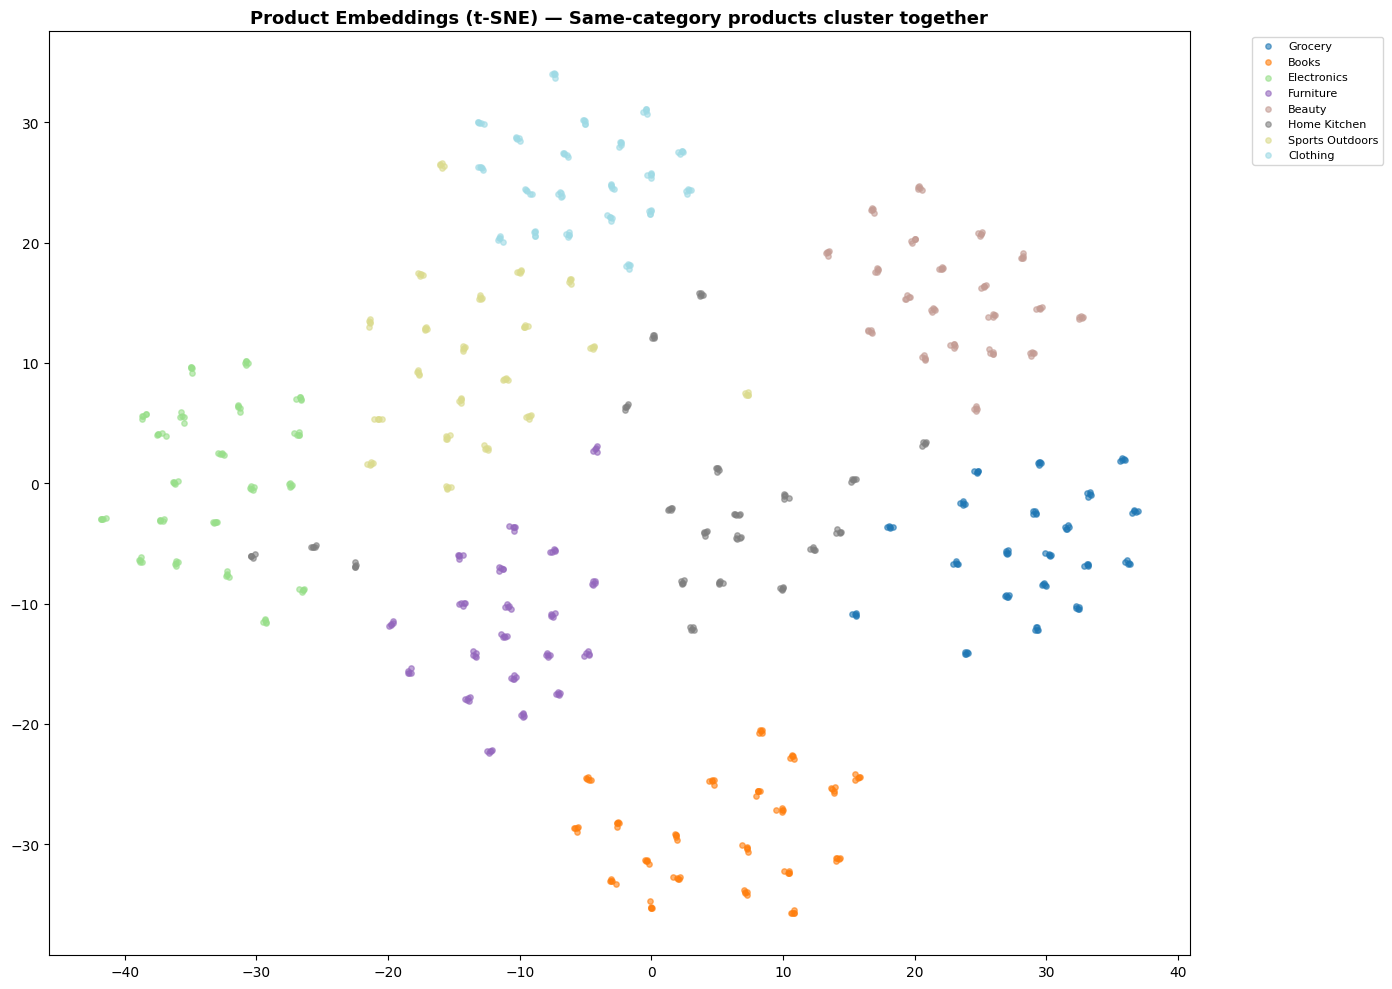

In [10]:
# ── Visualization ──
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

print("🔄 Computing t-SNE visualization...")
VIS_N = min(1500, len(df))
vis_idx = np.random.choice(len(df), VIS_N, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(sbert_embeddings[vis_idx])

fig, ax = plt.subplots(figsize=(14, 10))
cats = df.iloc[vis_idx]['category'].values
unique_cats = list(set(cats))
colors = plt.cm.tab20(np.linspace(0, 1, min(20, len(unique_cats))))

for i, cat in enumerate(unique_cats[:20]):
    mask = cats == cat
    ax.scatter(coords[mask, 0], coords[mask, 1], c=[colors[i%20]],
               label=cat[:22], alpha=0.6, s=15)

ax.set_title('Product Embeddings (t-SNE) — Same-category products cluster together', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
OUTPUT_DIR = 'model_export'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("💾 Exporting model files...")

# 1. TF-IDF
tfidf_path = os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.pkl')
joblib.dump(tfidf_vectorizer, tfidf_path)
print(f"   ✅ tfidf_vectorizer.pkl ({os.path.getsize(tfidf_path)/1024/1024:.1f} MB)")

# 2. SBERT
sbert_path = os.path.join(OUTPUT_DIR, 'sbert_model')
sbert_model.save(sbert_path)
sbert_size = sum(os.path.getsize(os.path.join(dp, f)) for dp, _, fn in os.walk(sbert_path) for f in fn)
print(f"   ✅ sbert_model/ ({sbert_size/1024/1024:.1f} MB)")

# 3. Metadata
metadata = {
    'model_version': '2.0.0',
    'model_type': 'hybrid_tfidf_sbert',
    'sbert_base': 'all-MiniLM-L6-v2',
    'sbert_embedding_dim': 384,
    'tfidf_max_features': 15000,
    'tfidf_ngram_range': [1, 2],
    'training_dataset_size': len(df),
    'training_categories': list(df['category'].unique()[:30]),
    'trained_at': datetime.now().isoformat(),
    'tfidf_weight': 0.35,
    'sbert_weight': 0.65,
}
with open(os.path.join(OUTPUT_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"   ✅ model_metadata.json")

print(f"\n📁 All files saved to '{OUTPUT_DIR}/'")

💾 Exporting model files...
   ✅ tfidf_vectorizer.pkl (0.1 MB)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ✅ sbert_model/ (87.3 MB)
   ✅ model_metadata.json

📁 All files saved to 'model_export/'


In [12]:
# ── Create ZIP and download ──
import shutil

zip_name = 'recommendation_model'
shutil.make_archive(zip_name, 'zip', OUTPUT_DIR)
zip_size = os.path.getsize(f'{zip_name}.zip') / 1024 / 1024
print(f"📦 Created {zip_name}.zip ({zip_size:.1f} MB)")

try:
    from google.colab import files
    print("\n📥 Downloading...")
    files.download(f'{zip_name}.zip')
except ImportError:
    print(f"📁 Saved at: {os.path.abspath(f'{zip_name}.zip')}")

print(f"""
{'='*60}
  📋 SETUP INSTRUCTIONS
{'='*60}

  1. Extract recommendation_model.zip into:
     backend/ml_models/

  2. Your folder should look like:
     backend/ml_models/
       ├── tfidf_vectorizer.pkl
       ├── model_metadata.json
       └── sbert_model/
            ├── config.json
            ├── model.safetensors
            ├── tokenizer.json
            └── ...

  3. Install Python deps:
     cd backend
     pip install flask flask-cors sentence-transformers
                 scikit-learn joblib numpy

  4. Start the Python recommendation service:
     python recommendation_service.py

  5. Start Node.js backend (calls Python service)

  6. Visit any product page — AI recommendations! 🎉
{'='*60}
""")

📦 Created recommendation_model.zip (79.6 MB)

📥 Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  📋 SETUP INSTRUCTIONS

  1. Extract recommendation_model.zip into:
     backend/ml_models/

  2. Your folder should look like:
     backend/ml_models/
       ├── tfidf_vectorizer.pkl
       ├── model_metadata.json
       └── sbert_model/
            ├── config.json
            ├── model.safetensors
            ├── tokenizer.json
            └── ...

  3. Install Python deps:
     cd backend
     pip install flask flask-cors sentence-transformers
                 scikit-learn joblib numpy

  4. Start the Python recommendation service:
     python recommendation_service.py

  5. Start Node.js backend (calls Python service)

  6. Visit any product page — AI recommendations! 🎉



In [13]:
# Reload from exported files (simulating production)
loaded_tfidf = joblib.load(os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.pkl'))
loaded_sbert = SentenceTransformer(os.path.join(OUTPUT_DIR, 'sbert_model'))

# COMPLETELY NEW products (never seen by the model)
new_products = [
    {'_id': '1', 'name': 'Samsung Galaxy S25 Ultra', 'description': '6.9 inch Dynamic AMOLED smartphone Snapdragon processor 200MP camera 5000mAh battery S Pen', 'category': 'Electronics'},
    {'_id': '2', 'name': 'Organic Baby Spinach 500g', 'description': 'Fresh organic baby spinach triple washed ready to eat salad greens nutritious leafy vegetables', 'category': 'Grocery'},
    {'_id': '3', 'name': 'Linen Throw Pillow Covers 18x18 Set', 'description': 'Decorative linen pillow covers farmhouse style hidden zipper washable living room sofa decor', 'category': 'Home'},
    {'_id': '4', 'name': 'Nike Air Max Running Shoes', 'description': 'Lightweight mesh running shoes Air Max cushioning responsive foam rubber outsole breathable', 'category': 'Sports'},
    {'_id': '5', 'name': 'La Roche-Posay Effaclar Cleanser', 'description': 'Purifying foaming gel cleanser oily sensitive skin zinc pidolate soap-free dermatologist tested', 'category': 'Beauty'},
    {'_id': '6', 'name': 'IKEA KALLAX Shelf Unit White', 'description': 'Modular shelving unit 4x4 cube storage organizer bookcase room divider white clean modern', 'category': 'Furniture'},
    {'_id': '7', 'name': 'Nintendo Switch OLED Console', 'description': 'Gaming console 7-inch OLED screen handheld tabletop TV mode Joy-Con controllers 64GB storage', 'category': 'Electronics'},
    {'_id': '8', 'name': 'Patagonia Better Sweater Fleece', 'description': 'Recycled polyester fleece jacket full-zip stand-up collar fair trade sewn warm layering outdoor', 'category': 'Clothing'},
]

TFIDF_WEIGHT = 0.35
SBERT_WEIGHT = 0.65

def product_to_text(p):
    return f"{p['name']} {p['name']} Category: {p.get('category', '')} {p.get('description', '')}"

catalog_texts = [product_to_text(p) for p in new_products]

print("="*70)
print("🧪 TESTING ON COMPLETELY UNSEEN PRODUCTS")
print("="*70)

for query_product in new_products:
    query_text = product_to_text(query_product)
    all_texts = [query_text] + catalog_texts

    # TF-IDF scores
    tfidf_vecs = loaded_tfidf.transform(all_texts)
    tfidf_sims = cosine_similarity(tfidf_vecs[0:1], tfidf_vecs[1:])[0]

    # SBERT scores
    sbert_vecs = loaded_sbert.encode(all_texts, normalize_embeddings=True)
    sbert_sims = cosine_similarity(sbert_vecs[0:1], sbert_vecs[1:])[0]

    # Hybrid
    scores = TFIDF_WEIGHT * tfidf_sims + SBERT_WEIGHT * sbert_sims
    # Exclude self
    for i, p in enumerate(new_products):
        if p['_id'] == query_product['_id']:
            scores[i] = -1

    top3 = np.argsort(scores)[-3:][::-1]
    print(f"\n🛍️  '{query_product['name']}'  [{query_product['category']}]")
    for r, i in enumerate(top3, 1):
        p = new_products[i]
        print(f"   {r}. {p['name']:40s} [{p['category']:12s}] score={scores[i]:.3f}")

print(f"\n{'='*70}")
print("✅ Model works on completely unseen products!")
print("   Your client can add ANY product — it just works. 🎉")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

🧪 TESTING ON COMPLETELY UNSEEN PRODUCTS

🛍️  'Samsung Galaxy S25 Ultra'  [Electronics]
   1. Nintendo Switch OLED Console             [Electronics ] score=0.256
   2. Nike Air Max Running Shoes               [Sports      ] score=0.164
   3. IKEA KALLAX Shelf Unit White             [Furniture   ] score=0.116

🛍️  'Organic Baby Spinach 500g'  [Grocery]
   1. IKEA KALLAX Shelf Unit White             [Furniture   ] score=0.173
   2. La Roche-Posay Effaclar Cleanser         [Beauty      ] score=0.142
   3. Linen Throw Pillow Covers 18x18 Set      [Home        ] score=0.132

🛍️  'Linen Throw Pillow Covers 18x18 Set'  [Home]
   1. IKEA KALLAX Shelf Unit White             [Furniture   ] score=0.232
   2. Patagonia Better Sweater Fleece          [Clothing    ] score=0.192
   3. Organic Baby Spinach 500g                [Grocery     ] score=0.132

🛍️  'Nike Air Max Running Shoes'  [Sports]
   1. Patagonia Better Sweater Fleece          [Clothing    ] score=0.187
   2. Samsung Galaxy S25 Ultra    